In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/__results__.html
/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/__notebook__.ipynb
/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/__output__.json
/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/custom.css
/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/Prepared_Dataset/5_min/y.npy
/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/Prepared_Dataset/5_min/X.npy
/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/Prepared_Dataset/15_min/y.npy
/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/Prepared_Dataset/15_min/X.npy
/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/Prepared_Dataset/25_min/y.n

In [2]:
# ============================================================
# Install Required Packages
# ============================================================

!pip -q install EMD-signal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 3.0 MB/s eta 0:00:00


In [3]:
# ============================================================
# Imports
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from scipy.signal import hilbert

from PIL import Image

from PyEMD import EMD

warnings.filterwarnings("ignore")

In [4]:
# ============================================================
# Dataset Paths
# ============================================================

DATA_ROOT = "/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/Prepared_Dataset"

OUTPUT_ROOT = "/kaggle/working/Hilbert_Dataset"

prediction_windows = [30,25,20,15,10,5]

os.makedirs(
    OUTPUT_ROOT,
    exist_ok=True
)

print("Input :", DATA_ROOT)
print("Output:", OUTPUT_ROOT)

Input : /kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/Prepared_Dataset
Output: /kaggle/working/Hilbert_Dataset


In [5]:
# ============================================================
# Configuration
# ============================================================

FS = 250

SEGMENT_LENGTH = 500

IMAGE_SIZE = (224, 224)

MAX_IMFS = 6

LEAD = 0

print("Sampling Rate :", FS)
print("Segment Length :", SEGMENT_LENGTH)
print("Maximum IMFs :", MAX_IMFS)
print("Image Size :", IMAGE_SIZE)
print("Selected Lead :", LEAD)

Sampling Rate : 250
Segment Length : 500
Maximum IMFs : 6
Image Size : (224, 224)
Selected Lead : 0


In [6]:
# ============================================================
# Load Prepared Dataset
# ============================================================

def load_dataset(minute):

    folder = os.path.join(
        DATA_ROOT,
        f"{minute}_min"
    )

    X = np.load(
        os.path.join(folder, "X.npy")
    )

    y = np.load(
        os.path.join(folder, "y.npy")
    )

    return X, y

In [7]:
# ============================================================
# Verify Dataset
# ============================================================

minute = 30

X, y = load_dataset(minute)

print("ECG Shape :", X.shape)
print("Labels Shape :", y.shape)

print()

print("Positive Samples :", np.sum(y == 1))
print("Negative Samples :", np.sum(y == 0))

print()

print("One ECG Shape :", X[0].shape)

print("ECG Data Type :", X.dtype)

print("Minimum :", X.min())

print("Maximum :", X.max())

ECG Shape : (2400, 500, 2)
Labels Shape : (2400,)

Positive Samples : 1200
Negative Samples : 1200

One ECG Shape : (500, 2)
ECG Data Type : float64
Minimum : -5.605
Maximum : 3.53


In [8]:
# ============================================================
# Repair Missing ECG Samples
# ============================================================

def repair_ecg(ecg):
    """
    Repair missing values (NaNs) in each ECG lead using
    linear interpolation.

    This repair is applied ONLY before EMD.
    The original dataset is never modified.
    """

    ecg = ecg.copy().astype(np.float64)

    for lead in range(ecg.shape[1]):

        x = ecg[:, lead]

        nan_mask = np.isnan(x)

        if not nan_mask.any():
            continue

        valid_mask = ~nan_mask

        if valid_mask.sum() == 0:
            x[:] = 0.0
        else:
            x[nan_mask] = np.interp(
                np.flatnonzero(nan_mask),
                np.flatnonzero(valid_mask),
                x[valid_mask]
            )

        ecg[:, lead] = x

    return ecg

In [9]:
# ============================================================
# Empirical Mode Decomposition
# ============================================================

from PyEMD import EMD

emd = EMD()

def perform_emd(
    ecg,
    lead=0,
    max_imfs=6
):
    """
    Perform Empirical Mode Decomposition (EMD)
    on one ECG segment.

    Parameters
    ----------
    ecg : ndarray
        Shape = (500, 2)

    lead : int
        ECG lead to use

    max_imfs : int
        Maximum number of IMFs

    Returns
    -------
    signal : ndarray
        Shape = (500,)

    imfs : ndarray
        Shape = (n_imfs, 500)
    """

    ecg = repair_ecg(ecg)

    signal = ecg[:, lead].astype(np.float64)

    imfs = emd(signal)

    if imfs.ndim == 1:
        imfs = imfs[np.newaxis, :]

    if imfs.shape[0] > max_imfs:
        imfs = imfs[:max_imfs]

    if imfs.size == 0:
        raise ValueError("No IMF extracted.")

    return signal, imfs

In [10]:
# ============================================================
# Verify EMD
# ============================================================

signal, imfs = perform_emd(X[0])

print("Signal Shape :", signal.shape)
print("IMFs Shape :", imfs.shape)
print("Number of IMFs :", len(imfs))

Signal Shape : (500,)
IMFs Shape : (6, 500)
Number of IMFs : 6


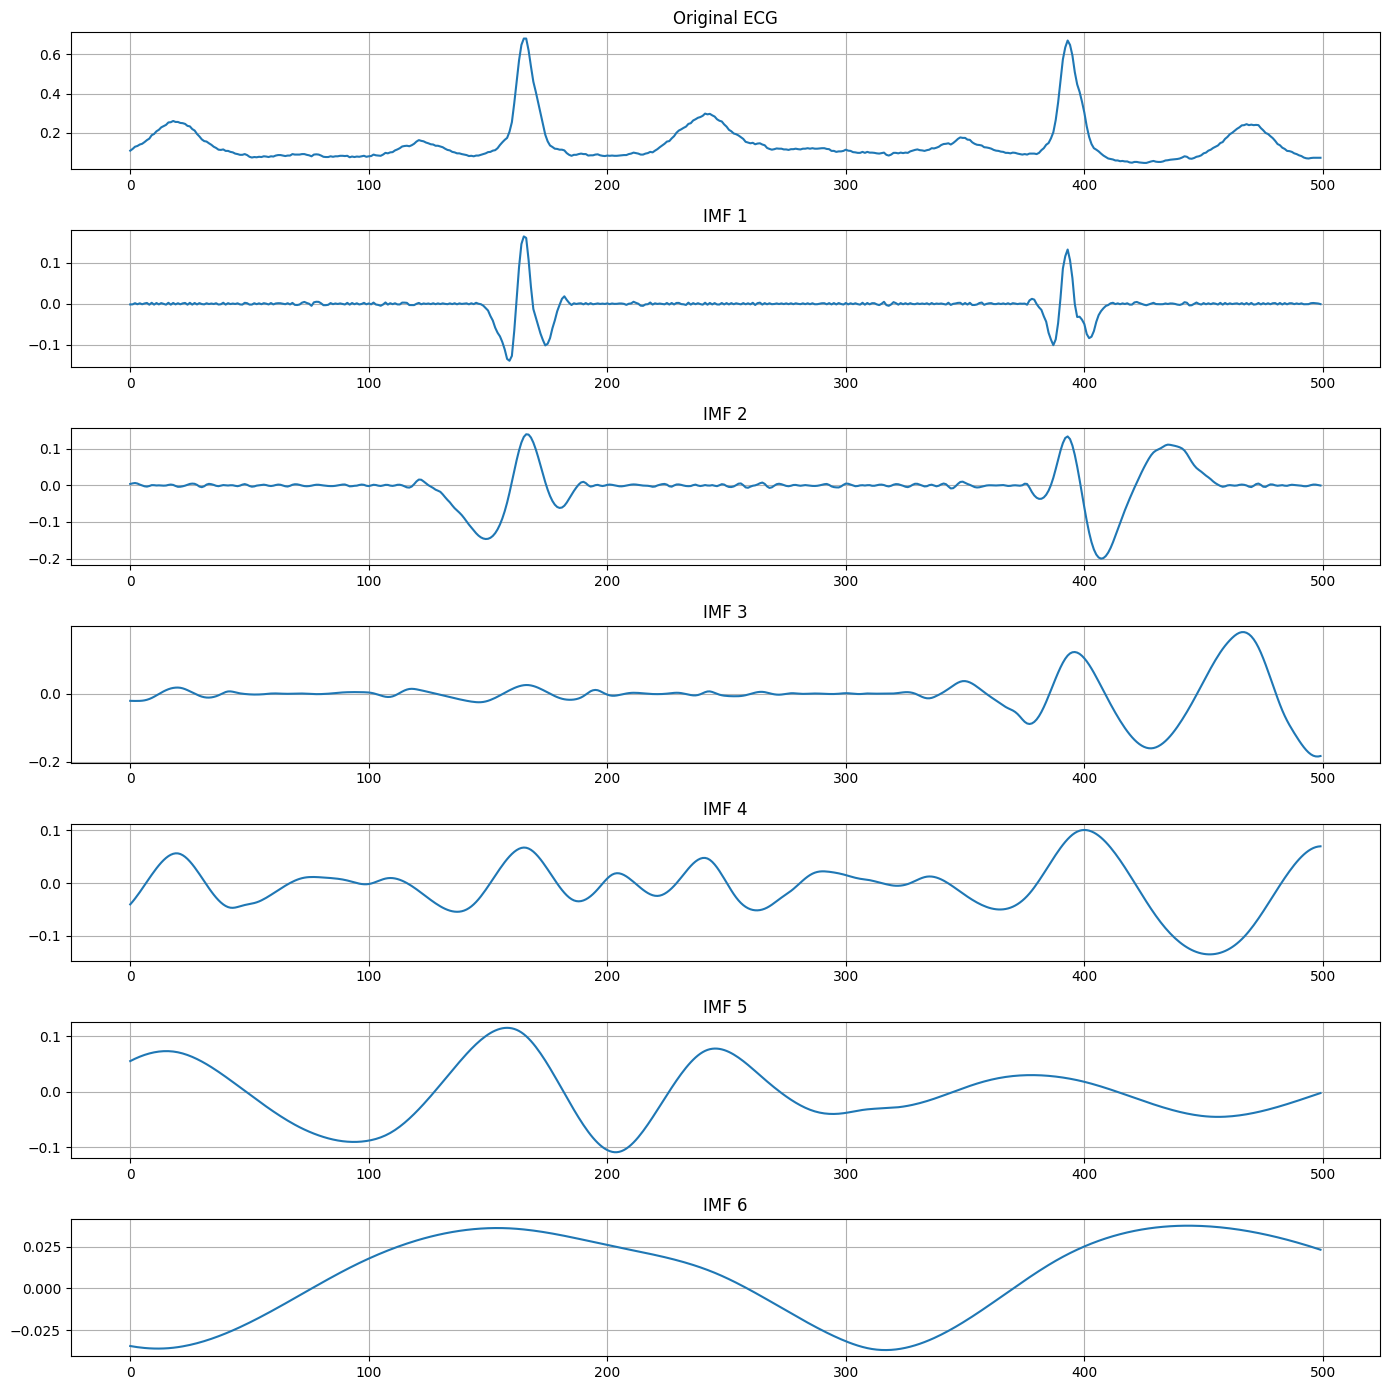

In [11]:
# ============================================================
# Visualize IMF Decomposition
# ============================================================

max_imfs = 6

num_imfs = min(imfs.shape[0], max_imfs)

plt.figure(figsize=(14, 2 * (num_imfs + 1)))

# Original ECG
plt.subplot(num_imfs + 1, 1, 1)
plt.plot(signal)
plt.title("Original ECG")
plt.grid(True)

# IMFs
for i in range(num_imfs):

    plt.subplot(num_imfs + 1, 1, i + 2)

    plt.plot(imfs[i])

    plt.title(f"IMF {i+1}")

    plt.grid(True)

plt.tight_layout()

plt.show()

In [14]:
# ============================================================
# Generate Hilbert Spectrum (Hilbert-Huang Transform)
# ============================================================

from scipy.signal import hilbert
from scipy.ndimage import gaussian_filter

def generate_hilbert_spectrum(
    imfs,
    fs=250,
    freq_bins=224,
    max_freq=125
):
    """
    Generate a Hilbert Spectrum from IMF components.

    Parameters
    ----------
    imfs : ndarray
        Shape = (n_imfs, 500)

    fs : int
        Sampling frequency

    freq_bins : int
        Number of frequency bins

    max_freq : int
        Maximum frequency displayed

    Returns
    -------
    spectrum : ndarray
        Shape = (224, 500)
    """

    n_imfs, n_samples = imfs.shape

    spectrum = np.zeros(
        (freq_bins, n_samples),
        dtype=np.float32
    )

    for imf in imfs:

        analytic = hilbert(imf)

        amplitude = np.abs(analytic)

        phase = np.unwrap(np.angle(analytic))

        instantaneous_frequency = (
            np.diff(phase) * fs / (2 * np.pi)
        )

        # Match lengths
        instantaneous_frequency = np.append(
            instantaneous_frequency,
            instantaneous_frequency[-1]
        )

        for t in range(n_samples):

            f = instantaneous_frequency[t]

            if not np.isfinite(f):
                continue

            if f < 0:
                continue

            if f > max_freq:
                continue

            row = int(
                np.clip(
                    (f / max_freq) * (freq_bins - 1),
                    0,
                    freq_bins - 1
                )
            )

            spectrum[row, t] += amplitude[t]

    spectrum = gaussian_filter(
        spectrum,
        sigma=1.0
    )

    return spectrum

In [15]:
# ============================================================
# Normalize Hilbert Spectrum
# ============================================================

def normalize_spectrum(spectrum):

    spectrum = np.log1p(spectrum)

    spectrum -= spectrum.min()

    maximum = spectrum.max()

    if maximum > 0:
        spectrum /= maximum

    return spectrum.astype(np.float32)

In [16]:
# ============================================================
# Test Hilbert Spectrum Generation
# ============================================================

signal, imfs = perform_emd(X[0])

spectrum = generate_hilbert_spectrum(
    imfs,
    fs=FS
)

spectrum = normalize_spectrum(spectrum)

print("Signal Shape   :", signal.shape)
print("IMFs Shape     :", imfs.shape)
print("Spectrum Shape :", spectrum.shape)

print("Minimum :", spectrum.min())
print("Maximum :", spectrum.max())

assert np.isfinite(spectrum).all()

assert spectrum.min() >= 0

assert spectrum.max() <= 1

Signal Shape   : (500,)
IMFs Shape     : (6, 500)
Spectrum Shape : (224, 500)
Minimum : 0.0
Maximum : 1.0


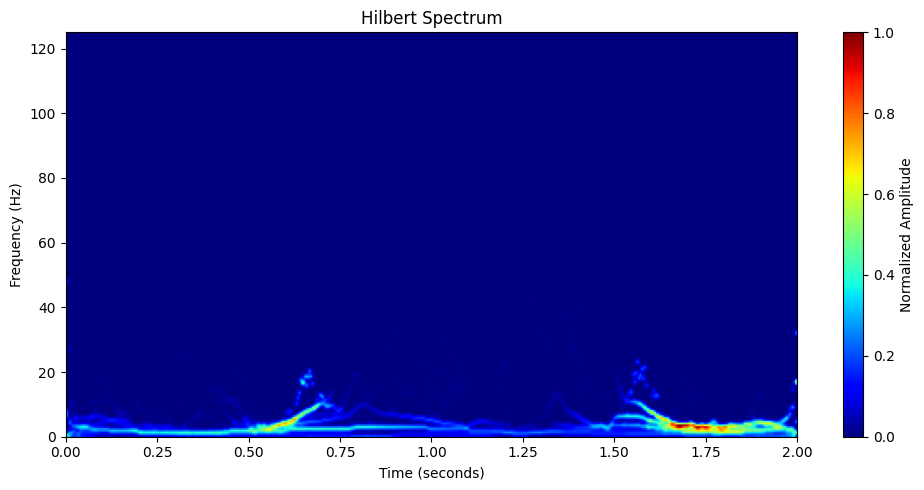

In [17]:
# ============================================================
# Visualize Hilbert Spectrum
# ============================================================

plt.figure(figsize=(10, 5))

plt.imshow(
    spectrum,
    origin="lower",
    aspect="auto",
    cmap="jet",
    extent=[0, 2, 0, FS/2]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.title("Hilbert Spectrum")

plt.colorbar(label="Normalized Amplitude")

plt.tight_layout()

plt.show()

In [18]:
# ============================================================
# Create Output Folders
# ============================================================

for minute in prediction_windows:

    positive_dir = os.path.join(
        OUTPUT_ROOT,
        f"{minute}_min",
        "Positive"
    )

    negative_dir = os.path.join(
        OUTPUT_ROOT,
        f"{minute}_min",
        "Negative"
    )

    os.makedirs(
        positive_dir,
        exist_ok=True
    )

    os.makedirs(
        negative_dir,
        exist_ok=True
    )

print("Output directories created successfully.")

Output directories created successfully.


In [21]:
# ============================================================
# Save Hilbert Spectrum Image
# ============================================================

def save_hilbert_image(
    spectrum,
    save_path
):

    width = spectrum.shape[1]

    start = (width - 224) // 2

    spectrum = spectrum[:, start:start+224]

    plt.figure(figsize=(2.24,2.24), dpi=100)

    plt.imshow(
        spectrum,
        origin="lower",
        aspect="auto",
        cmap="jet",
        extent=[0,2,0,FS/2]
    )

    plt.axis("off")

    plt.subplots_adjust(
        left=0,
        right=1,
        top=1,
        bottom=0
    )

    plt.savefig(
        save_path,
        bbox_inches="tight",
        pad_inches=0
    )

    plt.close()

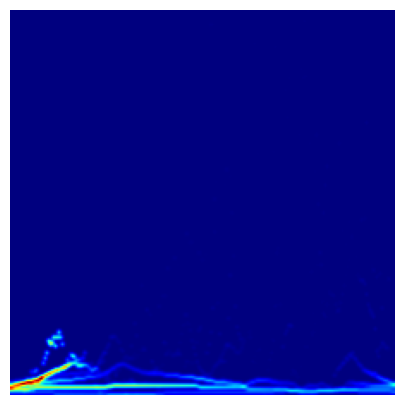

In [22]:
test_path = os.path.join(
    OUTPUT_ROOT,
    "test.png"
)

save_hilbert_image(
    spectrum,
    test_path
)

img = Image.open(test_path)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
# ============================================================
# Generate Complete Hilbert Spectrum Dataset
# ============================================================

import gc

for minute in prediction_windows:

    print(f"\n{'='*60}")
    print(f"Processing {minute} Minute Prediction Window")
    print(f"{'='*60}")

    X, y = load_dataset(minute)

    positive_dir = os.path.join(
        OUTPUT_ROOT,
        f"{minute}_min",
        "Positive"
    )

    negative_dir = os.path.join(
        OUTPUT_ROOT,
        f"{minute}_min",
        "Negative"
    )

    positive_count = 0
    negative_count = 0
    failed_count = 0

    for idx in tqdm(range(len(X))):

        try:

            signal, imfs = perform_emd(
                X[idx]
            )

            spectrum = generate_hilbert_spectrum(
                imfs,
                fs=FS
            )

            spectrum = normalize_spectrum(
                spectrum
            )

            if y[idx] == 1:

                save_path = os.path.join(
                    positive_dir,
                    f"{idx:05d}.png"
                )

                positive_count += 1

            else:

                save_path = os.path.join(
                    negative_dir,
                    f"{idx:05d}.png"
                )

                negative_count += 1

            save_hilbert_image(
                spectrum,
                save_path
            )

        except Exception as e:

            failed_count += 1

            print(f"\nFailed Sample {idx}")
            print(type(e).__name__)
            print(e)

        gc.collect()

    print()
    print(f"Positive Images : {positive_count}")
    print(f"Negative Images : {negative_count}")
    print(f"Failed Images   : {failed_count}")


Processing 30 Minute Prediction Window


  0%|          | 0/2400 [00:00<?, ?it/s]


Positive Images : 1200
Negative Images : 1200
Failed Images   : 0

Processing 25 Minute Prediction Window


  0%|          | 0/2400 [00:00<?, ?it/s]


Positive Images : 1200
Negative Images : 1200
Failed Images   : 0

Processing 20 Minute Prediction Window


  0%|          | 0/2400 [00:00<?, ?it/s]


Positive Images : 1200
Negative Images : 1200
Failed Images   : 0

Processing 15 Minute Prediction Window


  0%|          | 0/2400 [00:00<?, ?it/s]


Positive Images : 1200
Negative Images : 1200
Failed Images   : 0

Processing 10 Minute Prediction Window


  0%|          | 0/2400 [00:00<?, ?it/s]